<a href="https://colab.research.google.com/github/PrabhjeeSingh/DataScienceCorrelation/blob/main/Correlation_BondsYield_and_Political_climate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Correlation between Political Climate and Bonds yield


The data used in this notebook is from Twitter from October 2022 from a fixed population of British Twitter users, as well as data on the price of sovereign debt in the UK over the same time
horizon.


## Importing files and Libraries

*Uploading Files*

In [ ]:
#  loads the data files
from google.colab import files
uploaded = files.upload()

In [ ]:
uploaded = files.upload()

*Importing Required Python Libraries*

In [ ]:
##  Importing Libraries
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from nltk.corpus import stopwords
from operator import itemgetter
import nltk
import statsmodels.api as sm
import sklearn.linear_model
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

Here the output reflects that packages have been downloaded

## Creating DataFrames

*Creating DataFrames from the csv files for all the given data files*

In [ ]:
#  Load government bonds data
bonds = pd.read_csv("bonds.csv")

In [ ]:
# Load all the tweets files
tweets0 = pd.read_csv("chunk_00000.csv.gz")
tweets1 = pd.read_csv("chunk_00001.csv.gz")
tweets2 = pd.read_csv("chunk_00002.csv.gz")
tweets3 = pd.read_csv("chunk_00003.csv.gz")
tweets4 = pd.read_csv("chunk_00004.csv.gz")
tweets5 = pd.read_csv("chunk_00005.csv.gz")

In [ ]:
# Load user information
user_info = pd.read_csv("info_users.csv", delimiter=";")

## Preview the files

*Analysing how the data looks for each category of files*

In [ ]:
# preview of the bonds file
bonds.head()

,date,10y
0,2022-10-12,4.417
1,2022-10-13,4.192
2,2022-10-14,4.388
3,2022-10-17,3.974
4,2022-10-18,3.948


We have the dates and 10-year sovereign bond yield of the UK

In [ ]:
bonds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    15 non-null     object 
 1   10y     15 non-null     float64
dtypes: float64(1), object(1)
memory usage: 368.0+ bytes


We have the data type for both of the columns in the bonds file

*We will be only checking one of the tweets file since rest are similar*

In [ ]:
tweets0.head()

,tweet_id,user_id,text,date,anxiety,anger,sadness,nb_original,nb_answer,nb_retweet
0,1581925729297608705,1047179837125873664,RT @raplineshero: anime watchers in a nutshell...,1665995459,0.0,0.0,0.0,0.0,0.0,1.0
1,1581922164982558721,1047179837125873664,Fact https://t.co/izj2RyLgav,1665994609,0.0,0.0,0.0,1.0,0.0,0.0
2,1582440450145017856,615190328,@KeithMaxwell21 I know! I hardly dared to ment...,1666118178,0.0,0.0,0.0,0.0,1.0,0.0
3,1582430760253894656,615190328,"Well, I can confirm that being a good host pay...",1666115868,0.0,0.0,0.0,1.0,0.0,0.0
4,1582427279028023296,615190328,@Timberloo Been swimming?,1666115038,0.0,0.0,0.0,0.0,1.0,0.0


We observe that there are three columns for emotions (anxiety, anger and sadness)

*Checking one of the tweets chunck file for the count and data type of the columns*

In [ ]:
tweets0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 663015 entries, 0 to 663014
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   tweet_id     663015 non-null  int64  
 1   user_id      663015 non-null  int64  
 2   text         663015 non-null  object 
 3   date         663015 non-null  int64  
 4   anxiety      663015 non-null  float64
 5   anger        663015 non-null  float64
 6   sadness      663015 non-null  float64
 7   nb_original  663015 non-null  float64
 8   nb_answer    663015 non-null  float64
 9   nb_retweet   663015 non-null  float64
dtypes: float64(6), int64(3), object(1)
memory usage: 50.6+ MB


We could see that the date column is in int64 while the text column is of an object(str) data type

*Checking the user info file*

In [ ]:
user_info.head()

,id,gender,age,region
0,1047179837125873664,female,0,yorkshire and the humber
1,615190328,male,3,south west england
2,4064843607,male,1,london
3,42423705,female,1,yorkshire and the humber
4,116481654,male,2,east midlands england


We observe that we have different lengths of ids, age and region

*Checking for further information on the data type and columns*

In [ ]:
user_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32339 entries, 0 to 32338
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      32339 non-null  int64 
 1   gender  32339 non-null  object
 2   age     32339 non-null  int64 
 3   region  32339 non-null  object
dtypes: int64(2), object(2)
memory usage: 1010.7+ KB


We observe there are 32339 users in total

## Data Preparation


*Combining all 6 tweets DataFrames*

In [ ]:
# combine all tweets DataFrames
tweet_dfs = [tweets0, tweets1, tweets2, tweets3, tweets4, tweets5]
tweets = pd.concat([df for df in tweet_dfs], ignore_index=True)

*Veryfying the outcome of the tweets DataFrame*

In [ ]:
tweets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3165449 entries, 0 to 3165448
Data columns (total 10 columns):
 #   Column       Dtype  
---  ------       -----  
 0   tweet_id     int64  
 1   user_id      int64  
 2   text         object 
 3   date         int64  
 4   anxiety      float64
 5   anger        float64
 6   sadness      float64
 7   nb_original  float64
 8   nb_answer    float64
 9   nb_retweet   float64
dtypes: float64(6), int64(3), object(1)
memory usage: 241.5+ MB


We observe that our total no. of entries increased to 3165448

### Data Cleaning

*Removing the user info where user's age is under 18*

In [ ]:
# Remove users below 18 (value 0).
users_filtered = user_info[user_info['age'] > 0]
users_filtered['age'].value_counts()

,count
age,
1,10770
3,10022
2,7400


By removing people under age 18, we refine the dataset with people likely to be either engaged with or influencers of the political debates. Since they do not have voting rights and rarely contribute to creating the prevailing political atmosphere, their input would skew this analysis into something less representative for what the project has set to achieve.

*Checking for duplicate users*

In [ ]:
users_filtered.duplicated(subset='id').sum()

0

*Checking for duplicate tweets*

In [ ]:
tweets.duplicated(subset='tweet_id').sum()

538590

// Tweets0 file and Tweets# can contain the same tweets


*Removing the duplicated tweets*

In [ ]:
# Delete duplicate tweets
tweets = tweets.drop_duplicates(subset='tweet_id')

### Combining Users & Tweets

*merges the tweets DataFrame with the filtered user information based on user IDs.*

In [ ]:
# Merging tweets with the User Information
tweets = tweets.merge(users_filtered, left_on='user_id', right_on='id', how='left')
tweets.head()

,tweet_id,user_id,text,date,anxiety,anger,sadness,nb_original,nb_answer,nb_retweet,id,gender,age,region
0,1581925729297608705,1047179837125873664,RT @raplineshero: anime watchers in a nutshell...,1665995459,0.0,0.0,0.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN
1,1581922164982558721,1047179837125873664,Fact https://t.co/izj2RyLgav,1665994609,0.0,0.0,0.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN
2,1582440450145017856,615190328,@KeithMaxwell21 I know! I hardly dared to ment...,1666118178,0.0,0.0,0.0,0.0,1.0,0.0,615190328.0,male,3.0,south west england
3,1582430760253894656,615190328,"Well, I can confirm that being a good host pay...",1666115868,0.0,0.0,0.0,1.0,0.0,0.0,615190328.0,male,3.0,south west england
4,1582427279028023296,615190328,@Timberloo Been swimming?,1666115038,0.0,0.0,0.0,0.0,1.0,0.0,615190328.0,male,3.0,south west england


It's interesting to note that the merged DataFrame now contains additional columns for user demographics, which will help us analyze sentiments based on age and region.


*Removing the tweets with no user information*

In [ ]:
tweets = tweets.dropna(subset=['id'])

In [ ]:
tweets.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2359537 entries, 2 to 2626858
Data columns (total 14 columns):
 #   Column       Dtype  
---  ------       -----  
 0   tweet_id     int64  
 1   user_id      int64  
 2   text         object 
 3   date         int64  
 4   anxiety      float64
 5   anger        float64
 6   sadness      float64
 7   nb_original  float64
 8   nb_answer    float64
 9   nb_retweet   float64
 10  id           float64
 11  gender       object 
 12  age          float64
 13  region       object 
dtypes: float64(8), int64(3), object(3)
memory usage: 270.0+ MB


In [ ]:
tweets.head()

,tweet_id,user_id,text,date,anxiety,anger,sadness,nb_original,nb_answer,nb_retweet,id,gender,age,region
2,1582440450145017856,615190328,@KeithMaxwell21 I know! I hardly dared to ment...,1666118178,0.0,0.0,0.0,0.0,1.0,0.0,615190328.0,male,3.0,south west england
3,1582430760253894656,615190328,"Well, I can confirm that being a good host pay...",1666115868,0.0,0.0,0.0,1.0,0.0,0.0,615190328.0,male,3.0,south west england
4,1582427279028023296,615190328,@Timberloo Been swimming?,1666115038,0.0,0.0,0.0,0.0,1.0,0.0,615190328.0,male,3.0,south west england
5,1582413015726493708,615190328,@binkyjh She’s learning fast!,1666111637,0.0,0.0,0.0,0.0,1.0,0.0,615190328.0,male,3.0,south west england
6,1582412700709421058,615190328,"@agoldentale Hi Duds, I wonder if he’s a dista...",1666111562,0.0,0.0,0.0,0.0,1.0,0.0,615190328.0,male,3.0,south west england


### Fix Datetime Format

*Converting the date format from seconds in the tweets DataFrame to have the datetime format*

In [ ]:
# Convert timestamp to datetime
tweets.loc[:, 'date'] = pd.to_datetime(tweets['date'], unit='s')
tweets['date']

,date
2,2022-10-18 18:36:18
3,2022-10-18 17:57:48
4,2022-10-18 17:43:58
5,2022-10-18 16:47:17
6,2022-10-18 16:46:02
...,...
2626854,2022-10-27 12:01:12
2626855,2022-10-30 19:20:40
2626856,2022-10-30 09:59:27
2626857,2022-10-27 21:42:56


we observe that date has been updated into a better format which will be better to analyze.

## Data Analysis


*Plotting the 4 important graphs*

*Classify each number of tweets with the corresponding date*

In [ ]:
# Tweets data: Group by date
tweets['date_only'] = tweets['date'].dt.date  # Extract the date part
tweets_per_day = tweets.groupby('date_only')['id'].count().reset_index()
tweets_per_day.columns = ['date', 'no_of_tweets']
tweets_per_day

,date,no_of_tweets
0,2022-10-12,115010
1,2022-10-13,111820
2,2022-10-14,138041
3,2022-10-15,117482
4,2022-10-16,121521
5,2022-10-17,132240
6,2022-10-18,121601
7,2022-10-19,143410
8,2022-10-20,166555
9,2022-10-21,136177


The period during which there was the most tweets was between october 19th and october 21st.

Interesting Note: There are only 2 tweets of data present for 31st October

*classify every number of tweets with the corresponding region*

In [ ]:
# Tweets data: Group by date
tweets_per_region = tweets.groupby('region')['id'].count().reset_index()
tweets_per_region.columns = ['region', 'no_of_tweets']
tweets_per_region

,region,no_of_tweets
0,east midlands england,123228
1,east of england,151106
2,london,690231
3,north east england,43915
4,north west england,229842
5,northern ireland,39104
6,scotland,284126
7,south east england,212359
8,south west england,177657
9,wales,112731


We observe that the number of tweets made in London were highest

*classify every tweet by age*

In [ ]:
# Tweets by age: Merge user info and group by age
tweets_by_age = tweets.groupby('age')['tweet_id'].count().reset_index()
tweets_by_age.columns = ['age', 'no_of_tweets']

*This code is going to plot all the classifaction that we did above;  each number of tweets with the corresponding date, every number of tweets with the corresponding region, each bonds for the coresponding day and classify every tweet by age.*

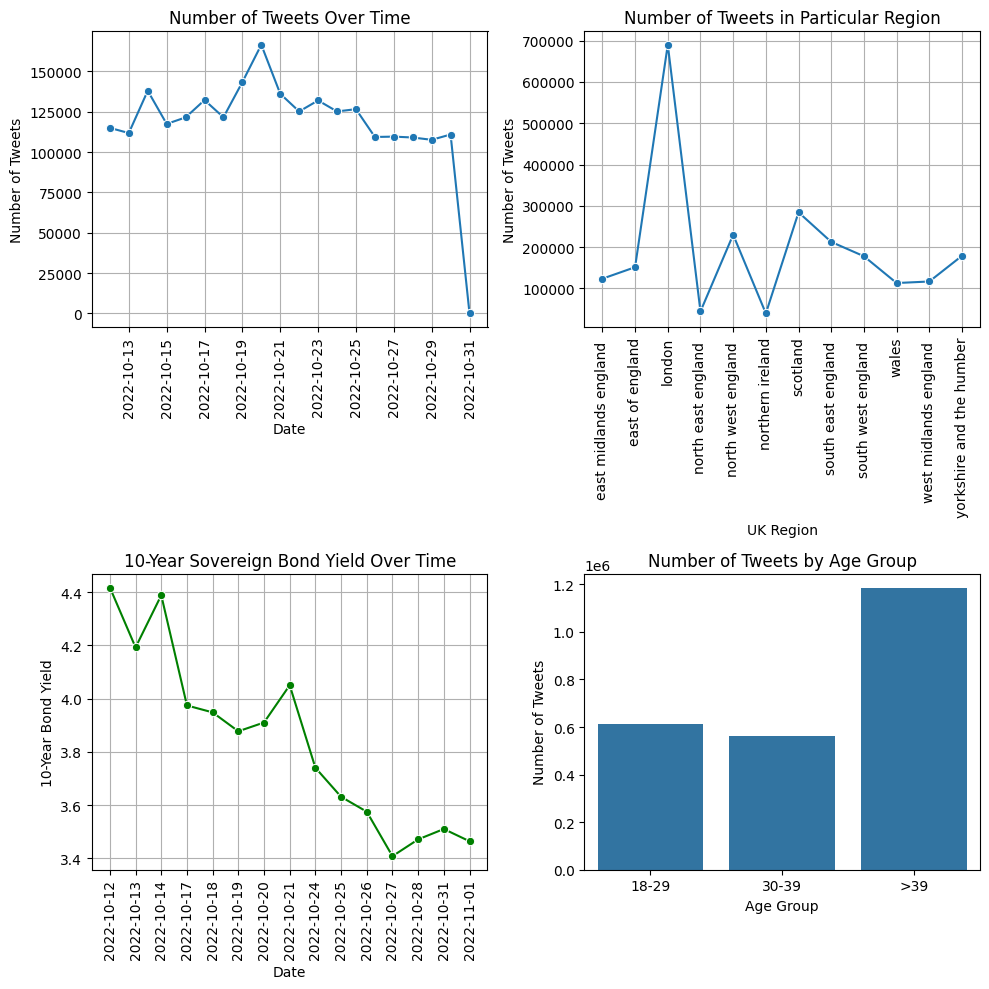

In [ ]:
#  Create the figure and axes
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

ax1, ax2 = axes[0]  # First row
ax3, ax4 = axes[1]  # Second row

# Plot 1: Date vs Number of Tweets
sns.lineplot(data=tweets_per_day, x='date', y='no_of_tweets', ax=ax1, marker='o')
ax1.set_title('Number of Tweets Over Time')
ax1.set_xlabel('Date')
ax1.set_ylabel('Number of Tweets')
ax1.tick_params(axis='x', rotation=90)
ax1.grid(True)

# Plot 2: Region vs Number of Tweets
sns.lineplot(data=tweets_per_region, x='region', y='no_of_tweets', ax=ax2, marker='o')
ax2.set_title('Number of Tweets in Particular Region')
ax2.set_xlabel('UK Region')
ax2.set_ylabel('Number of Tweets')
ax2.tick_params(axis='x', rotation=90)
ax2.grid(True)

# Plot 3: Bonds vs Date
sns.lineplot(data=bonds, x='date', y='10y', ax=ax3, color='green', marker='o')
ax3.set_title('10-Year Sovereign Bond Yield Over Time')
ax3.set_xlabel('Date')
ax3.set_ylabel('10-Year Bond Yield')
ax3.tick_params(axis='x', rotation=90)
ax3.grid(True)

# Plot 4: Number of Tweets by Age
sns.barplot(data=tweets_by_age, x='age', y='no_of_tweets', ax=ax4)
ax4.set_title('Number of Tweets by Age Group')
ax4.set_xlabel('Age Group')
ax4.set_ylabel('Number of Tweets')
ax4.set_xticks([0, 1, 2])
ax4.set_xticklabels(['18-29', '30-39', '>39'])


# Adjust layout for clarity
plt.tight_layout()
plt.show()

By ploting thoses graphs we can observe the period during which people tweet the most, the region that as the most tweet, the age range which tweetthe most and in the same time frame we have the 10 year sovereign bond yield.



**Number of Tweets Over Time (Top Left)**:


We could see there is a spiike in number of tweets between October 19th and October 21st, indicating crucial event in the area of politics.

**Number of Tweets by Region (Top Right):**


London stands out with most number of tweets made. This also demonstrates that London is a hub for politics, economic and social discussions.

**Time Series of 10-Year Sovereign Bond Yield (Bottom Left):**



The bond yield graph has been showing a consistent decline over time however we could see the certain spike in the interest rate around October 21st which indicates something big happened that might changed public emotions.

**Number of Tweets by Age Group (Bottom Right):**


Users aged 39 and above are the most contributory to tweets activity. While the other 2 groups 18-30 and 30-39 have similar frequency of tweets. This indicates the different priorities and engagement levels by age group and experience.

*Dropping the tweets made after 30th*

In [ ]:
tweets = tweets[tweets['date'].dt.date <= pd.to_datetime('2022-10-30').date()]

*Checking if the code worked and removed all the tweets made after 30th*

In [ ]:
tweets_per_day = tweets.groupby('date_only')['id'].count().reset_index()
tweets_per_day

,date_only,id
0,2022-10-12,115010
1,2022-10-13,111820
2,2022-10-14,138041
3,2022-10-15,117482
4,2022-10-16,121521
5,2022-10-17,132240
6,2022-10-18,121601
7,2022-10-19,143410
8,2022-10-20,166555
9,2022-10-21,136177


We observe that now in total, we have 19 dates of tweets data

### Dropping the bonds after 31st

*Converting the bonds date column to match that of tweets date column by converting them to datetime format*

In [ ]:
bonds['date'] = pd.to_datetime(bonds['date'])

In [ ]:
bonds = bonds[bonds['date'].dt.date <= pd.to_datetime('2022-10-31').date()]

In [ ]:
bonds

,date,10y
0,2022-10-12,4.417
1,2022-10-13,4.192
2,2022-10-14,4.388
3,2022-10-17,3.974
4,2022-10-18,3.948
5,2022-10-19,3.877
6,2022-10-20,3.910
7,2022-10-21,4.050
8,2022-10-24,3.740
9,2022-10-25,3.631


We observe that we have successfully dropped 1 bonds value dated Nov 1st, since we do not have the tweets data for this date.

# Most common keywords

*This code will create empty list in which all the 'text' from tweets into a single string so they can be convert into a TextBlob format to count the occurences of each word.*

In [ ]:
all_text = " ".join(tweets['text'])

*Convert 'all_text' into a TextBlob format and call the output blob.*

In [ ]:
blob = TextBlob(all_text)
word_counts_textblob = blob.word_counts

 *Produces word frequency tuples*

In [ ]:
word_count_dict = word_counts_textblob.items()

*Removing stopwords from the word_count_dict*

In [ ]:
stop_words_eng = stopwords.words('english')

In [ ]:
# Remove the stopwords from 'word_count_dict'
word_count_dict = [ word for word in word_count_dict if word[0] not in stop_words_eng]

 The resulting sorted list highlights the most relevant words used in the tweets.

In [ ]:
# Sort 'word_count_dict' in a descending order using the sorted() function.
sorted_word_count_dict = sorted(word_count_dict, key=itemgetter(1), reverse=True)

# Print 'sorted_word_count_dict'.
sorted_word_count_dict

[('rt', 1123063),
 ('https', 655119),
 ('’', 557874),
 ("n't", 135198),
 ('one', 108031),
 ('like', 106106),
 ('people', 102670),
 ('amp', 102566),
 ('get', 85264),
 ('would', 79576),
 ('“', 77432),
 ('time', 76213),
 ('good', 71939),
 ('think', 66233),
 ('new', 62364),
 ('”', 60588),
 ('back', 59927),
 ('know', 58374),
 ('us', 57304),
 ('today', 56164),
 ('see', 54958),
 ('truss', 52679),
 ('need', 51435),
 ('day', 48437),
 ('going', 48140),
 ('go', 47386),
 ('uk', 46771),
 ('got', 46523),
 ('tory', 46358),
 ('well', 46182),
 ('right', 44834),
 ('want', 44816),
 ('still', 44264),
 ('really', 44239),
 ('last', 44193),
 ('years', 43594),
 ('love', 42306),
 ('could', 41964),
 ('never', 41796),
 ('first', 41258),
 ('much', 41226),
 ('party', 40469),
 ('even', 40334),
 ('johnson', 39994),
 ('‘', 38824),
 ('great', 37930),
 ('make', 37814),
 ('sunak', 37279),
 ('government', 36676),
 ('…', 36632),
 ('say', 35790),
 ('please', 35496),
 ('way', 34577),
 ('man', 34225),
 ('many', 33822),
 ('ta

We can see a dictionary of word counts, which highlights the most frequently used words in the tweets.

*Printing top 150 words most frequently used words from the sorted word count dictionary.*

In [ ]:
# Select the 150 most used words.
top150 = sorted_word_count_dict[0:150]
top150

[('rt', 1123063),
 ('https', 655119),
 ('’', 557874),
 ("n't", 135198),
 ('one', 108031),
 ('like', 106106),
 ('people', 102670),
 ('amp', 102566),
 ('get', 85264),
 ('would', 79576),
 ('“', 77432),
 ('time', 76213),
 ('good', 71939),
 ('think', 66233),
 ('new', 62364),
 ('”', 60588),
 ('back', 59927),
 ('know', 58374),
 ('us', 57304),
 ('today', 56164),
 ('see', 54958),
 ('truss', 52679),
 ('need', 51435),
 ('day', 48437),
 ('going', 48140),
 ('go', 47386),
 ('uk', 46771),
 ('got', 46523),
 ('tory', 46358),
 ('well', 46182),
 ('right', 44834),
 ('want', 44816),
 ('still', 44264),
 ('really', 44239),
 ('last', 44193),
 ('years', 43594),
 ('love', 42306),
 ('could', 41964),
 ('never', 41796),
 ('first', 41258),
 ('much', 41226),
 ('party', 40469),
 ('even', 40334),
 ('johnson', 39994),
 ('‘', 38824),
 ('great', 37930),
 ('make', 37814),
 ('sunak', 37279),
 ('government', 36676),
 ('…', 36632),
 ('say', 35790),
 ('please', 35496),
 ('way', 34577),
 ('man', 34225),
 ('many', 33822),
 ('ta

we can observe that from this list of words, some of them are political and those are the ones we would be focusing on.

# Remove Non Political Tweets

*This code is a curated list of the most political terms used in the tweets by the users.*

In [ ]:
political_words =['#liztruss',
 '#rishisunak',
 '#tory',
 '#costoflivingcrisis',
 '#brexit',
 '#nationaldebt',
 '#borisjohnson',
 '#trussresigns',
 '#toryleadership',
 '#bankofengland',
 '#economiccrisis',
 '#nhs',
 '#climatechange',
 '#immigration',
 '#pmqs',
 '#generalelection',
 '#unions',
 '#fuelcrisis',
 '#unionjack',
 '#keirstarmer',
 '#ukpolitics',
 '#theresamay',
 '#sadiqkhan',
 '#levellingup',
 '#energycrisis',
 '#foodbanks',
 '#greenenergy',
 '#peoplesvote',
 '#publicservices',
 '#taxcuts',
 '#publicsector',
 '#britain',
 '#truss',
 '#uk',
 '#party',
 '#johnson',
 '#sunak',
 '#government',
 '#boris',
 '#liz',
 '#pm',
 '#country',
 '#minister',
 '#prime',
 '#tories'
 'liztruss',
 'rishisunak',
 'tory',
 'brexit',
 'borisjohnson',
 'nhs',
 'immigration',
 'pmqs',
 'generalelection',
 'unions',
 'foodbanks',
 'peoplesvote',
 'britain',
 'truss',
 'uk',
 'party',
 'johnson',
 'sunak',
 'government',
 'boris',
 'liz',
 'pm',
 'country',
 'minister',
 'prime',
 'tories',
 'election',
 'win',
 'rishi',
 'news',
 'public']

After analyzing the word frequency in the tweets, we also cross-referenced with the Google Trends data **[3]** and added some new words to the list. Adding #s to these keywords ensures we capture a wider range of tweets.

These keywords would be helpful in determining whether the tweets are likely to reflect political opinions, discussion and reactions or not.

*Filter tweets based on the presence of political keywords*

In [ ]:
# Function to check if a tweet contains any political keywords
def contains_political_keywords(tweet, keywords):
    # Convert the tweet to lowercase and check if any keyword is in the tweet
    return any(keyword.lower() in tweet.lower() for keyword in keywords)

# Filter the tweets based on the presence of political keywords
political_tweets = tweets[tweets['text'].apply(lambda x: contains_political_keywords(x, political_words))]


In [ ]:
political_tweets

,tweet_id,user_id,text,date,anxiety,anger,sadness,nb_original,nb_answer,nb_retweet,id,gender,age,region,date_only,sentiment_score,emotions_avg
3,1582430760253894656,615190328,"Well, I can confirm that being a good host pay...",2022-10-18 17:57:48,0.0,0.000000,0.0,1.0,0.0,0.0,615190328.0,male,3.0,south west england,2022-10-18,0.350000,0.000000
6,1582412700709421058,615190328,"@agoldentale Hi Duds, I wonder if he’s a dista...",2022-10-18 16:46:02,0.0,0.000000,0.0,0.0,1.0,0.0,615190328.0,male,3.0,south west england,2022-10-18,0.351852,0.000000
30,1581916433411604480,615190328,@HighlandIsla @EdwinandHubble @MrKiplingwoof @...,2022-10-17 07:54:02,0.0,0.000000,0.0,0.0,1.0,0.0,615190328.0,male,3.0,south west england,2022-10-17,0.437500,0.000000
37,1581713475000500224,615190328,@moiragraham25 Quite a family history.,2022-10-16 18:27:33,0.0,0.000000,0.0,0.0,1.0,0.0,615190328.0,male,3.0,south west england,2022-10-16,0.000000,0.000000
40,1581710149773053952,615190328,@MrKiplingwoof @SusieQT16 @Jemima114 @peanuts1...,2022-10-16 18:14:21,0.0,0.000000,0.0,0.0,1.0,0.0,615190328.0,male,3.0,south west england,2022-10-16,0.600000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2626835,1585063844883623938,371453496,RT @silvcrwings: “You came here as a craven an...,2022-10-26 00:20:44,0.0,0.000000,0.0,0.0,0.0,1.0,371453496.0,male,1.0,south east england,2022-10-26,0.433333,0.000000
2626839,1585061736415375360,371453496,RT @RReece_: Daenerys haters are going to be s...,2022-10-26 00:12:21,0.0,0.100000,0.0,0.0,0.0,1.0,371453496.0,male,1.0,south east england,2022-10-26,0.433333,0.033333
2626846,1584586476075249664,371453496,RT @ingoIdo: i am once again asking why on ear...,2022-10-24 16:43:50,0.0,0.153846,0.0,0.0,0.0,1.0,371453496.0,male,1.0,south east england,2022-10-24,0.000000,0.051282
2626854,1585602512492568577,24523087,A funded pre-seed fintech startup is looking f...,2022-10-27 12:01:12,0.0,0.000000,0.0,1.0,0.0,0.0,24523087.0,male,1.0,london,2022-10-27,-0.050000,0.000000


We can observe that we only kept political tweets and number of tweets decreased to 702733.

## TextBlob Sentiment Analysis

*This code create and empty list named 'sentiment' and calculate the emotional scores for each political tweet.*

In [ ]:
sentiment = []

for tweet in political_tweets['text']:
    analysis = TextBlob(tweet)
    sentiment.append(analysis.sentiment.polarity)

political_tweets.loc[:, 'sentiment_score'] = sentiment

*Checking if the sentiment score appears in the political tweets*

In [ ]:
political_tweets.head()

,tweet_id,user_id,text,date,anxiety,anger,sadness,nb_original,nb_answer,nb_retweet,id,gender,age,region,date_only,sentiment_score
3,1582430760253894656,615190328,"Well, I can confirm that being a good host pay...",2022-10-18 17:57:48,0.0,0.0,0.0,1.0,0.0,0.0,615190328.0,male,3.0,south west england,2022-10-18,0.350000
6,1582412700709421058,615190328,"@agoldentale Hi Duds, I wonder if he’s a dista...",2022-10-18 16:46:02,0.0,0.0,0.0,0.0,1.0,0.0,615190328.0,male,3.0,south west england,2022-10-18,0.351852
30,1581916433411604480,615190328,@HighlandIsla @EdwinandHubble @MrKiplingwoof @...,2022-10-17 07:54:02,0.0,0.0,0.0,0.0,1.0,0.0,615190328.0,male,3.0,south west england,2022-10-17,0.437500
37,1581713475000500224,615190328,@moiragraham25 Quite a family history.,2022-10-16 18:27:33,0.0,0.0,0.0,0.0,1.0,0.0,615190328.0,male,3.0,south west england,2022-10-16,0.000000
40,1581710149773053952,615190328,@MrKiplingwoof @SusieQT16 @Jemima114 @peanuts1...,2022-10-16 18:14:21,0.0,0.0,0.0,0.0,1.0,0.0,615190328.0,male,3.0,south west england,2022-10-16,0.600000


We calculated the sentiment score from negative(-1) to positive (+1). This step is crucial in identifying the emotions and the public sentiment about the political events happenning in UK.**[4]**

## Group Sentiments by Day

*This code groups the political tweets by date.*


In [ ]:
# Ensure 'date' column is in datetime format
political_tweets.loc[:, 'date'] = pd.to_datetime(political_tweets['date'])

*After grouping the political tweets by date, this code generates a new DataFrame "daily_sentiment" which is basically political tweets grouped by dates and the mean sentiment score for each day.*

In [ ]:
daily_sentiment = political_tweets.groupby(political_tweets['date'].dt.date)['sentiment_score'].mean()

In [ ]:
daily_sentiment

,sentiment_score
date,
2022-10-12,0.078298
2022-10-13,0.097041
2022-10-14,0.074092
2022-10-15,0.093674
2022-10-16,0.091131
2022-10-17,0.087627
2022-10-18,0.080868
2022-10-19,0.068963
2022-10-20,0.065213


It's interesting to note that we now have a DataFrame that summarizes daily sentiment, allowing us to track changes over time.

The sentiment scores show the overall emotional tone of tweets,

We observe that tweets had the sentiment in the range of 0.06-0.10 throughout the political turmoil. The lowest value was during the Truss's resignation that is on Oct 19-20.
while public sentiment showed optimism during the early days of the Sunak's government.

*This code merges the daily sentiment DataFrame with the bonds DataFrame based on the date, allowing us to analyze the relationship between sentiment and bond yields.*

*Making sure the daily_sentiment index is in the correct datetime object*

In [ ]:
daily_sentiment.index = pd.to_datetime(daily_sentiment.index)

*Merging the daily_sentiments DataFrame and bonds DataFrame*

In [ ]:
# Merge
sentiment_bonds_df = pd.merge(daily_sentiment, bonds, on='date', how ="outer")

In [ ]:
sentiment_bonds_df

,date,sentiment_score,10y
0,2022-10-12,0.078298,4.417
1,2022-10-13,0.097041,4.192
2,2022-10-14,0.074092,4.388
3,2022-10-15,0.093674,NaN
4,2022-10-16,0.091131,NaN
5,2022-10-17,0.087627,3.974
6,2022-10-18,0.080868,3.948
7,2022-10-19,0.068963,3.877
8,2022-10-20,0.065213,3.910
9,2022-10-21,0.074793,4.050


We can see that the merged DataFrame now contains both sentiment scores and bond yields, which will be crucial for our correlation analysis.
Note: we could see some NaN values here which is due to the weekends data being missing. We will fix these during the regression analysis because it might give some insights by just plotting the graph with NaN values.

*This code scales the sentiment scores by multiplying them by 30 to align the values with the bond yield scale for visualization purposes.*

In [ ]:
sentiment_bonds_df['sentiment_score_scaled'] = 30 * sentiment_bonds_df['sentiment_score']

the scaled sentiment scores will now be comparable to bond yields, facilitating a clearer visual analysis.


*This code creates a line plot for the scaled sentiment scores and a scatter plot for the bond yields over time.*


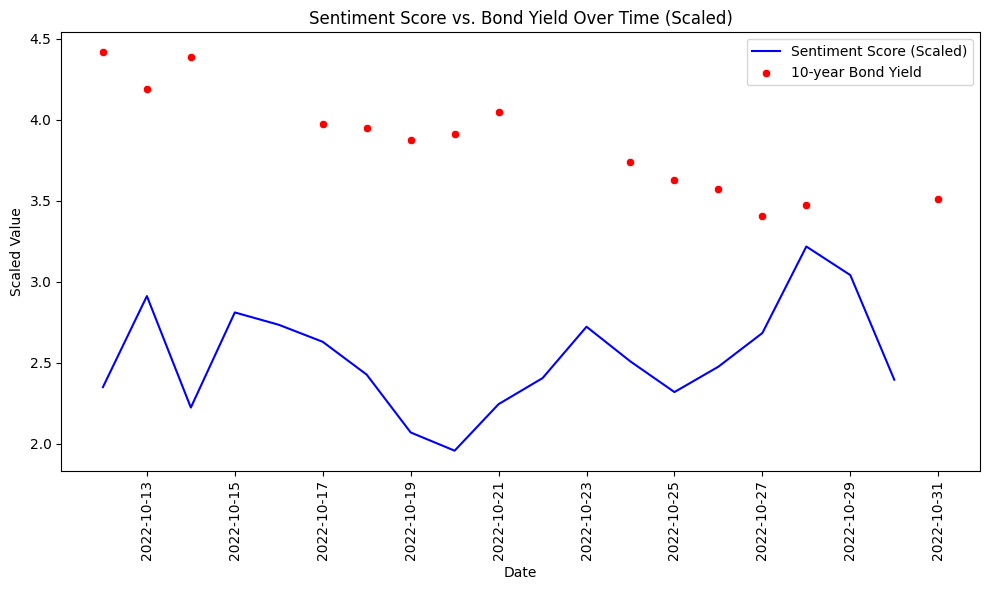

In [ ]:
# Plot the data
plt.figure(figsize=(10, 6))

# Plot scaled sentiment score
sns.lineplot(x='date', y='sentiment_score_scaled', data=sentiment_bonds_df, label='Sentiment Score (Scaled)', color='b')

# Plot bond yield
sns.scatterplot(x='date', y='10y', data=sentiment_bonds_df, label='10-year Bond Yield', color='r')

# Add labels and title
plt.title('Sentiment Score vs. Bond Yield Over Time (Scaled)')
plt.xlabel('Date')
plt.ylabel('Scaled Value')
plt.legend()

# Show the plot
plt.xticks(rotation=90)  # Rotate dates for better readability
plt.tight_layout()
plt.show()

Key Events**[2,3]** vs Data:

**Oct 12-14:**


*   Bond yields highest
*   Sentiment fluctuating
*  Events: Mini-budget crisis peak, market turmoil


**Oct 15-19:**

mini-budget U-turn

*   Bonds declining
*   Sentiment declining
*   Events: Jeremy Hunt appointed, mini-budget U-turn


**Oct 20-25:**
*   Bonds continuing decline
*   Sentiment rising slightly
*   Events: Truss resignation, Sunak's leadership contest


**Oct 26-31:**
*   Bonds stabilizing
*   Sentiment peaks then drops
*   Events: Sunak becomes PM, new government formation

We observe the relationship between sentiment and bond yields, which may indicate how public sentiment influences financial markets or vice versa. After a little a bit of research we have found that in September 28 of 2022 the bank of england announced it was buying 65 billions of government bonds after economic uncertainty.
When there is an instability in the bonds the population interpret that there is an economic or politique fragility. And it is reflected on the sentiment curve which is represent here.

We could see a clear correlation from October 12-14 when public sentiment was low ie. negative the bonds interest rate was high (Oct12 & 14) and vice versa on Oct 13.

We can see on the Graph that from October 17 to October 21 there is a drop on the sentiment curve. A drop  that can be explain by the tension in the political situation of the UK during this period  which result by the resignation of the Lizz Truss as a premier minister and and the reverse of her tax measures.  And Rishi sunak selected as new prime minister .


**Interesting to Note:**
While there was a clear correlation between the public sentiment, political climate and the bonds before Oct 23,
After Sunak was emerging as a clear successor we saw a mixed public reaction hence we could see the dip on Oct 25 when he was formally appointed. but the bonds yield remained on the decreasing path this was because of the markets reacted more decisively to Sunak's appointment given his financial background and promise of fiscal discipline but then from Oct 26th public opinion aligned after he gave his speech and with the market's reaction of "wait and see" approach.

## Robustness of our findings

*We used multiple methods to calculate political climate, leveraging emotional values like anger, anxiety, and sadness to ensure the robustness of our findings.*

*To mitigate user bias, we implemented a "1 sentiment, 1 user, 1 day" rule, which averaged the sentiment per day, ensuring that individual variations did not skew the overall analysis and provided a more accurate representation of political sentiment over time.*

### Robustness: Calculate the emotions avg

*This code calculates the average of the emotional scores (anxiety, anger, and sadness) for each political tweet and stores it in a new column called emotion_avg.*

In [ ]:
political_tweets.loc[:, 'emotions_avg'] = (
    political_tweets[['anxiety', 'anger', 'sadness']].mean(axis=1)
)

*Verifying the emotions avg*

In [ ]:
political_tweets['emotions_avg'].tail()

,emotions_avg
2626835,0.000000
2626839,0.033333
2626846,0.051282
2626854,0.000000
2626858,0.000000


We observe that the emotions_avg column now contains the average emotional score for each tweet, which will help us analyze the overall emotional tone of political discussions.

### Robustness - Emotions vs Sentiment

*Lets groups the political tweets by date and calculates the mean sentiment score and average emotions for each day.*

In [ ]:
daily_metrics = political_tweets.groupby(political_tweets['date'].dt.date).agg(
    daily_sentiment=('sentiment_score', 'mean'),
    daily_emotions_avg=('emotions_avg', 'mean')
)

*Making sure the daily_metrics index is in the correct datetime object*

In [ ]:
daily_metrics.index = pd.to_datetime(daily_metrics.index)

*Merging the daily_metrics DataFrame and bonds DataFrame*

In [ ]:
# Merge
robust_merged_df = pd.merge(daily_metrics, bonds, on='date', how ="outer")

In [ ]:
robust_merged_df

,date,daily_sentiment,daily_emotions_avg,10y
0,2022-10-12,0.078298,0.008396,4.417
1,2022-10-13,0.097041,0.008268,4.192
2,2022-10-14,0.074092,0.008608,4.388
3,2022-10-15,0.093674,0.008665,NaN
4,2022-10-16,0.091131,0.008331,NaN
5,2022-10-17,0.087627,0.008563,3.974
6,2022-10-18,0.080868,0.009222,3.948
7,2022-10-19,0.068963,0.009638,3.877
8,2022-10-20,0.065213,0.010170,3.910
9,2022-10-21,0.074793,0.009788,4.050


we now have a DataFrame that summarizes daily sentiment and emotional averages, allowing us to track changes over time.

*This code flipped the emotions by multiplying them by -1000 to make them comparable to the daily_sentiment for visualization purposes.*

In [ ]:
robust_merged_df['flipped_emotions'] = -1000 * robust_merged_df['daily_emotions_avg']

In [ ]:
robust_merged_df

,date,daily_sentiment,daily_emotions_avg,10y,flipped_emotions
0,2022-10-12,0.078298,0.008396,4.417,-8.396021
1,2022-10-13,0.097041,0.008268,4.192,-8.267998
2,2022-10-14,0.074092,0.008608,4.388,-8.608000
3,2022-10-15,0.093674,0.008665,NaN,-8.665161
4,2022-10-16,0.091131,0.008331,NaN,-8.330951
5,2022-10-17,0.087627,0.008563,3.974,-8.563229
6,2022-10-18,0.080868,0.009222,3.948,-9.221957
7,2022-10-19,0.068963,0.009638,3.877,-9.637735
8,2022-10-20,0.065213,0.010170,3.910,-10.169867
9,2022-10-21,0.074793,0.009788,4.050,-9.787660


Lets keep in mind that in a sentiment analysis the polarity is the sentiment from -1.0(negative) to 1.0(positive) with 0 being neutral, by flipping the daily emotion avg it will allow us to have a better graphical analyse and comparaison between the sentiment score curve and the daily emotion avg.

*This code creates a line plot for the scaled sentiment scores, the flipped emotions and a scatter plot for the bond yields over time.*


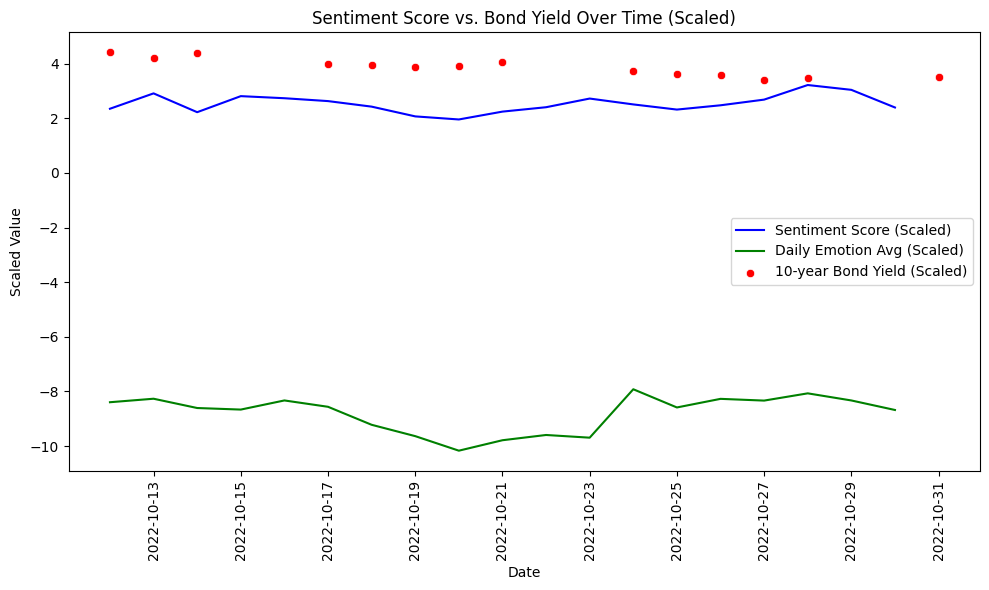

In [ ]:
# Plot the data
plt.figure(figsize=(10, 6))

# Plot Scaled sentiment score
sns.lineplot(x='date', y='sentiment_score_scaled', data=sentiment_bonds_df, label='Sentiment Score (Scaled)', color='b')
# Plot Scaled sentiment score
sns.lineplot(x='date', y='flipped_emotions', data=robust_merged_df, label='Daily Emotion Avg (Scaled)', color='g')

# Plot Scaled bond yield
sns.scatterplot(x='date', y='10y', data=robust_merged_df, label='10-year Bond Yield (Scaled)', color='r')

# Add labels and title
plt.title('Sentiment Score vs. Bond Yield Over Time (Scaled)')
plt.xlabel('Date')
plt.ylabel('Scaled Value')
plt.legend()

# Show the plot
# plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.xticks(rotation=90)  # Rotate dates for better readability
plt.tight_layout()
plt.show()

We can observe that the tendacy of the sentiment curve and the daily Emotion are pretty similar, that when the bond yield increases we observe a discontent that can be read on the sentiment score curve and the daily emotion avg during the majority of the graph.

However, the curve evolves a little different from October 17th until October 25th of the year 2022, periods during which the political situation in the UK is seen to have an impact on the population and therefore users on twitter and which is reflected trough the sentiment score and the daily emotion avg(anger, sadness, anxiety) .

### Robustness: Try with one user, one sentiment, one date

*This code sorts the political tweets based on the date and time*

In [ ]:
sorted_political_tweets = political_tweets.sort_values(by='date')

In [ ]:
sorted_political_tweets

,tweet_id,user_id,text,date,anxiety,anger,sadness,nb_original,nb_answer,nb_retweet,id,gender,age,region,date_only,sentiment_score,emotions_avg
776913,1579985206936621056,2945576998,"00:45 Temp. 4.7°C, Hum. 85%, Dewp. 1.7°C, Bar....",2022-10-12 00:00:02,0.000000,0.0,0.0,1.0,0.0,0.0,2.945577e+09,male,3.0,south east england,2022-10-12,0.000000,0.000000
376638,1579985213144190978,320968942,"01:00 AM, Temp 10.3C feels like 10,3, Humidity...",2022-10-12 00:00:04,0.033333,0.0,0.0,1.0,0.0,0.0,3.209689e+08,male,3.0,scotland,2022-10-12,0.100000,0.011111
45795,1579985342920527873,1035516433,"00:43 BST: Temperature: 8.3°C, Wind: S, 0 mph ...",2022-10-12 00:00:35,0.062500,0.0,0.0,1.0,0.0,0.0,1.035516e+09,male,3.0,south west england,2022-10-12,-0.275000,0.020833
294701,1579985368648388608,877202968281587713,RT @99OARii: When we tell about ghost stories....,2022-10-12 00:00:41,0.000000,0.0,0.0,0.0,0.0,1.0,8.772030e+17,male,2.0,london,2022-10-12,0.000000,0.000000
106650,1579985400638345216,2857238196,RT @AMEA_YorksNE: In recent weeks members of t...,2022-10-12 00:00:48,0.000000,0.0,0.0,0.0,0.0,1.0,2.857238e+09,male,1.0,london,2022-10-12,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2289075,1586870387723456512,3235888239,"RT @chrisgreybrexit: This, from today's Sydney...",2022-10-30 23:59:17,0.000000,0.0,0.0,0.0,0.0,1.0,3.235888e+09,male,3.0,south west england,2022-10-30,0.000000,0.000000
2553155,1586870416622108674,64053993,RT @GOV2UK: A former UK Civil Servant was give...,2022-10-30 23:59:24,0.000000,0.0,0.0,0.0,0.0,1.0,6.405399e+07,female,3.0,south east england,2022-10-30,0.000000,0.000000
2367485,1586870489372413956,3092545725,"RT @TheBlacktastic: FGC, you know you can stop...",2022-10-30 23:59:41,0.000000,0.0,0.0,0.0,0.0,1.0,3.092546e+09,male,1.0,scotland,2022-10-30,-0.029762,0.000000
2188130,1586870519869181952,1039876149369864192,@Jamiebrodie7 @chriswood1875x hamilton didn’t ...,2022-10-30 23:59:49,0.000000,0.0,0.0,0.0,1.0,0.0,1.039876e+18,male,1.0,scotland,2022-10-30,0.266667,0.000000


We could oberve the tweets being sorted by date and time, But for our purpose here we do not need the time information

*Keeping only the date information in the DataFrame*

In [ ]:
sorted_political_tweets['date'] = sorted_political_tweets['date'].dt.date

In [ ]:
sorted_political_tweets['date'].head(n=2)

,date
776913,2022-10-12
376638,2022-10-12


We could see we only have date information now

*Checking the value counts of the users tweets in the sorted political tweets data frame*

In [ ]:
sorted_political_tweets['user_id'].value_counts()

,count
user_id,
21930807,3505
27841516,3479
402026873,3262
914377458,3256
1615111236,3120
...,...
302722364,1
19455067,1
2977358662,1


We observe that we have users who have made quite a lot of tweets as compared to other users

*This code is going to group the 'date' and the 'user_id' and calculate the mean sentiment score for each user on each date.*

In [ ]:
#  Group by 'date' and 'user_id' and calculate the mean sentiment score for each user on each date
mean_sentiment_per_user = sorted_political_tweets.groupby(['date', 'user_id'])['sentiment_score'].mean().reset_index()

In [ ]:
mean_sentiment_per_user

,date,user_id,sentiment_score
0,2022-10-12,246,0.140000
1,2022-10-12,73383,0.175947
2,2022-10-12,613223,0.700000
3,2022-10-12,664283,0.064286
4,2022-10-12,674433,0.000000
...,...,...,...
144665,2022-10-30,1194236078124912642,0.000000
144666,2022-10-30,1196255492793913345,0.010000
144667,2022-10-30,1199631096343932928,0.179167
144668,2022-10-30,1200740501185540096,0.485227


We could observe the sentiment score based on mean group by dates

*Checking the value counts for the sentiment scores based on the users now*

In [ ]:
mean_sentiment_per_user['user_id'].value_counts()

,count
user_id,
2460822622,19
913023860710297600,19
906891878804721664,19
352348861,19
2829414399,19
...,...
762213208568565760,1
758602062582210560,1
755096867537649664,1


We could observe that now we have at maximum 19 sentiment scores per user_id which matches the 19 days of data we originally have.

*Making sure the date is in the proper format*

In [ ]:
mean_sentiment_per_user['date'] = pd.to_datetime(mean_sentiment_per_user['date'])

*Calculating the mean by the date*

In [ ]:
mean_sentiment_per_user = mean_sentiment_per_user.groupby(mean_sentiment_per_user['date'])['sentiment_score'].mean()

In [ ]:
mean_sentiment_per_user

,sentiment_score
date,
2022-10-12,0.106942
2022-10-13,0.125699
2022-10-14,0.106070
2022-10-15,0.125677
2022-10-16,0.119943
2022-10-17,0.115793
2022-10-18,0.108438
2022-10-19,0.094114
2022-10-20,0.083851


This means that for every user, there is one sentiment score recorded per day, and these scores are collected across all users. By organizing the data in this way, we can analyze trends in sentiment without bias from repeated inputs from the same user on the same day.

*Merging the mean sentiment per user DataFrame with the bonds dataframe*

In [ ]:
# Merge
user_date_merged_df = pd.merge(mean_sentiment_per_user, bonds, on='date', how ="outer")

In [ ]:
user_date_merged_df

,date,sentiment_score,10y
0,2022-10-12,0.106942,4.417
1,2022-10-13,0.125699,4.192
2,2022-10-14,0.106070,4.388
3,2022-10-15,0.125677,NaN
4,2022-10-16,0.119943,NaN
5,2022-10-17,0.115793,3.974
6,2022-10-18,0.108438,3.948
7,2022-10-19,0.094114,3.877
8,2022-10-20,0.083851,3.910
9,2022-10-21,0.102146,4.050


We could see the merged data together, Note: we would not remove the NaN since we are plotting bonds data as a scatter plot which allows us to analyse the sentiment over the weekends as well.

*Scaling the sentiment score*

In [ ]:
user_date_merged_df['sentiment_score_scaled'] = 10 * user_date_merged_df[['sentiment_score']]

*This code creates a line plot for the  sentiment scores per user and a scatter plot for the bond yields over time.*

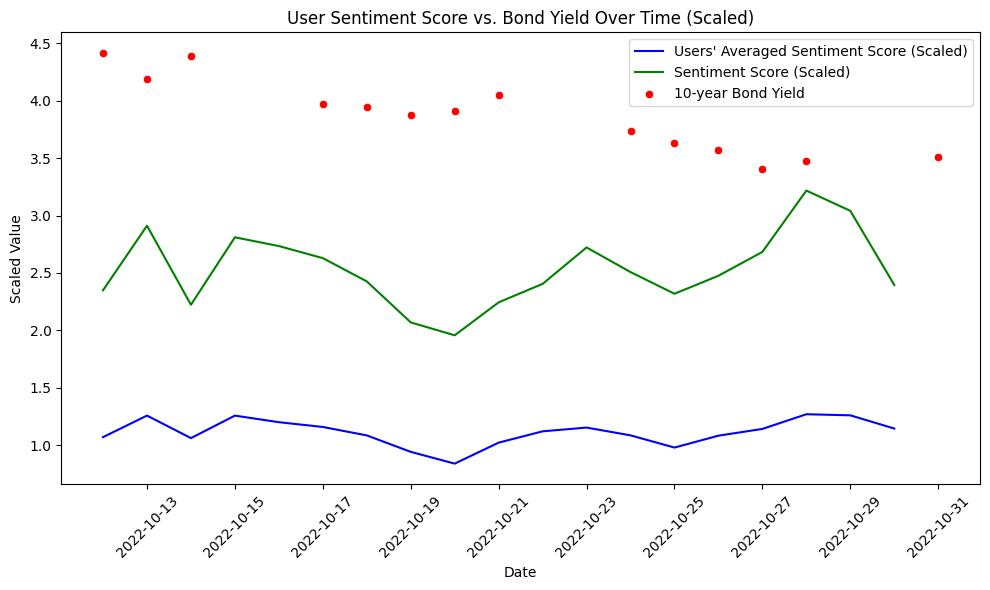

In [ ]:
# Plot the data
plt.figure(figsize=(10, 6))

# Plot scaled sentiment score
sns.lineplot(x='date', y='sentiment_score_scaled', data=user_date_merged_df, label="Users' Averaged Sentiment Score (Scaled)", color='b')

# Plot scaled sentiment score
sns.lineplot(x='date', y='sentiment_score_scaled', data=sentiment_bonds_df, label='Sentiment Score (Scaled)', color='g')

# Plot 10yr bond yield[
sns.scatterplot(x='date', y='10y', data=user_date_merged_df, label='10-year Bond Yield', color='r')

# Add labels and title
plt.title('User Sentiment Score vs. Bond Yield Over Time (Scaled)')
plt.xlabel('Date')
plt.ylabel('Scaled Value')
plt.legend()

# Show the plot
plt.xticks(rotation=45)  # Rotate dates for better readability
plt.tight_layout()
plt.show()

We could observe the "Users' Averaged Sentiment Score" and the underlying "Sentiment Score" are, in fact, showing the same trend since the former is a smoothed version of the latter.

It looks like the short-term noise is filtered out, while the overall direction remains the same.

Therefore, while they are not the same, they do signal the same message about the general movement of public sentiment over time.

Hence, we can conclude that our analysis is robust regardless of which method we
consider.


## Regression Model
We will be using linear regression to analyze the relationship between sentiment scores and the 10-year bond yield


### Linear Regression

*Checking the sentiment bonds df one more time*

In [ ]:
sentiment_bonds_df

,date,sentiment_score,10y,sentiment_score_scaled
0,2022-10-12,0.078298,4.417,2.348936
1,2022-10-13,0.097041,4.192,2.911231
2,2022-10-14,0.074092,4.388,2.222760
3,2022-10-15,0.093674,NaN,2.810207
4,2022-10-16,0.091131,NaN,2.733922
5,2022-10-17,0.087627,3.974,2.628816
6,2022-10-18,0.080868,3.948,2.426031
7,2022-10-19,0.068963,3.877,2.068886
8,2022-10-20,0.065213,3.910,1.956387
9,2022-10-21,0.074793,4.050,2.243794


We could observe some NaN values we would need to handle these values since model would not fit properly if do not handle these values

*This code uses the forward fill method to fill in the NaN values*
**[5]**  

In [ ]:
Forward_filled_final_df = sentiment_bonds_df.ffill()
Forward_filled_final_df

,date,sentiment_score,10y,sentiment_score_scaled
0,2022-10-12,0.078298,4.417,2.348936
1,2022-10-13,0.097041,4.192,2.911231
2,2022-10-14,0.074092,4.388,2.222760
3,2022-10-15,0.093674,4.388,2.810207
4,2022-10-16,0.091131,4.388,2.733922
5,2022-10-17,0.087627,3.974,2.628816
6,2022-10-18,0.080868,3.948,2.426031
7,2022-10-19,0.068963,3.877,2.068886
8,2022-10-20,0.065213,3.910,1.956387
9,2022-10-21,0.074793,4.050,2.243794


We could see the NaN values being replaced by the previous values,

Reasoning: Tweet volume remains substantial during weekends with bond trend being relatively smooth.
Therefore, preserving the weekend sentiment data which seeems might have signifcant relation.

Also the bond markets close on Friday and then reopen on Mondays where weekend tweets/events will impact monday's opening price, using friday's value for the weekend will maintain the temporal sequence reflecting actual information available to market particpant at a point in time to decide the future market price.

*Assigning the X and y feature variables*

In [ ]:
X = np.c_[Forward_filled_final_df[['sentiment_score']]]
y = np.c_[Forward_filled_final_df['10y']]

*Fitting(Training) the model on the X and y variables*

In [ ]:
model = sklearn.linear_model.LinearRegression()
model.fit(X,y)

LinearRegression()

We could see that Linear Regression was performed successfully

*Finding the regression coefficient found by the model*

In [ ]:
model.coef_

array([[-5.01057341]])

This confirms our previous analysis from Daily Sentiment Analysis section that there is a negative correlation betweent the public climate and the bond yields.

The coefficient is -5.01057341
 It means that for every increase of 1 unit in the sentiment score (Towards Political stability), the 10-year bond yield would decrease by approximately 5.01 units.

*Finding the intercept found by the model*

In [ ]:
model.intercept_

array([4.31725049])

The intercept is 4.31725049, which represents the expected bond yield when the sentiment score is zero. This value also serve as the baseline or starting point for the regression line when sentiment is neutral.



# References and Citation

1. **UK Politics Timeline**

    * 2022 In Politics: A Timeline Of Chaos From Partygate To The Mini-Budget. (2022, December 29). Politics Home. https://www.politicshome.com/news/article/2022-political-timeline-year-in-review-politics-boris-johnson-liz-truss-rishi-sunak

<br>

2. **October 2022 Timeline**
    * Wikipedia contributors. (2024b, November 6). 2022 in the United Kingdom. Wikipedia. https://en.wikipedia.org/wiki/2022_in_the_United_Kingdom


<br>

3. **Political Keyword Trends**
   * Google Trends. (n.d.). Trends. https://trends.google.com/trends?geo=GB&hl=en-US

<br>

4. **Sentiment Analysis and Political Climate Relation**

    * Using Sentiment Analysis for politics: the case of the Italian Political Elections. (2023). In Bachelor’s Degree in Management and Computer Science [Thesis]. https://tesi.luiss.it/36536/1/257751_LA%20GIOIA_ELIO%20SIMONE.pdf
<br>

    * Chambers, N., Jr., Bowen, V., Genco, E., Tian, X., Young, E., Harihara, G., Yang, E., Department of Computer Science, & United States Naval Academy. (n.d.). Identifying Political Sentiment between Nation States with Social Media. In Department of Computer Science [Journal-article]. https://www.usna.edu/Users/cs/nchamber/pubs/chambers-emnlp2015.pdf
<br>

    * Webster, S. W., & Albertson, B. (2022). Emotion and Politics: Noncognitive Psychological Biases in Public Opinion. Annual Review of Political Science, 25(1), 401–418. https://doi.org/10.1146/annurev-polisci-051120-105353
<br>


5. **Forward Fill Method**
    * pandas.DataFrame.ffill — pandas 2.2.3 documentation. (n.d.). https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.ffill.html